# **Time Series Forcasting**

We will:

Build forecasting models for Scope 1 and Scope 2

Generate baseline forecasts

Create scenario-based projections

Evaluate accuracy, stability, and sensitivity

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


/home/sundayofunmi/.pandas_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("curated_scope_wide.csv", parse_dates=["YearMonth"])
df = df.set_index("YearMonth")

df.head()


,SCOPE 1,SCOPE 2
YearMonth,,
2020-01-01,1755.795813,1908.584310
2020-02-01,1679.152641,1792.904592
2020-03-01,1871.382396,1920.870573
2020-04-01,1887.235869,1870.897161
2020-05-01,1999.483530,1913.012361


In [3]:
# Train/Test Split
# We hold out the last 20% for testing.
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (57, 2)
Test shape: (15, 2)


# **SARIMA Forecasting**

# Auto ARIMA (Scope 1)

In [4]:
# Auto ARIMA (Scope 1)
model_s1 = auto_arima(
    train["SCOPE 1"],
    seasonal=True,
    m=12,
    trace=True,
    stepwise=True
)

model_s1.summary()


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.20 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=411.955, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=410.401, Time=0.16 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=432.764, Time=0.01 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=413.950, Time=0.05 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=411.695, Time=0.37 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=0.90 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=408.409, Time=0.11 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=409.697, Time=0.27 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=0.48 sec

<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                 
================================================================================
Dep. Variable:                        y   No. Observations:                   57
Model:             SARIMAX(1, 1, 0, 12)   Log Likelihood                -201.204
Date:                  Mon, 09 Mar 2026   AIC                            408.409
Time:                          10:45:22   BIC                            413.829
Sample:                      01-01-2020   HQIC                           410.429
                           - 09-01-2024                                         
Covariance Type:                    opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -29.8337      7.083     -4.212      0.000     -43.717     -15.951
ar.S.L12      -0.4878      0.249     -1.958      0.050      -0.976       0.001
sigma2       413.3234     80.478      5.136      0.000     255.589     571.058
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.29
Prob(Q):                              0.90   Prob(JB):                         0.53
Heteroskedasticity (H):               1.44   Skew:                            -0.08
Prob(H) (two-sided):                  0.49   Kurtosis:                         3.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The highly significant intercept ($p < 0.001$) indicates a structural downward trend in emissions of approximately 29.83 $tCO2e$ per annum. The seasonal component confirms a 12-month cyclicality in the operational footprint.


In [5]:
# Fit SARIMA Model
sarima_s1 = SARIMAX(
    train["SCOPE 1"],
    order=model_s1.order,
    seasonal_order=model_s1.seasonal_order
).fit()

forecast_s1 = sarima_s1.forecast(steps=len(test))


In [6]:
forecast_s1

2024-10-01    1799.582700
2024-11-01    1689.446659
2024-12-01    1659.973751
2025-01-01    1686.483709
2025-02-01    1621.395260
2025-03-01    1770.809058
2025-04-01    1810.790966
2025-05-01    1933.853785
2025-06-01    1870.700438
2025-07-01    2002.736274
2025-08-01    1920.402806
2025-09-01    1798.582186
2025-10-01    1800.153965
2025-11-01    1690.426168
2025-12-01    1656.812553
Freq: MS, Name: predicted_mean, dtype: float64

In [7]:
# Evaluate Scope 1 SARIMA
mae_s1 = mean_absolute_error(test["SCOPE 1"], forecast_s1)
rmse_s1 = np.sqrt(mean_squared_error(test["SCOPE 1"], forecast_s1))

print("Scope 1 SARIMA MAE:", mae_s1)
print("Scope 1 SARIMA RMSE:", rmse_s1)


Scope 1 SARIMA MAE: 42.895040018994315
Scope 1 SARIMA RMSE: 50.395016880410715


In [8]:
df.describe()

,SCOPE 1,SCOPE 2
count,72.000000,72.000000
mean,1821.245789,1505.060492
std,138.744455,246.984936
min,1528.405722,1073.108649
25%,1714.555911,1294.340537
50%,1818.541622,1456.873473
75%,1942.664087,1745.582942
max,2074.481574,1920.870573


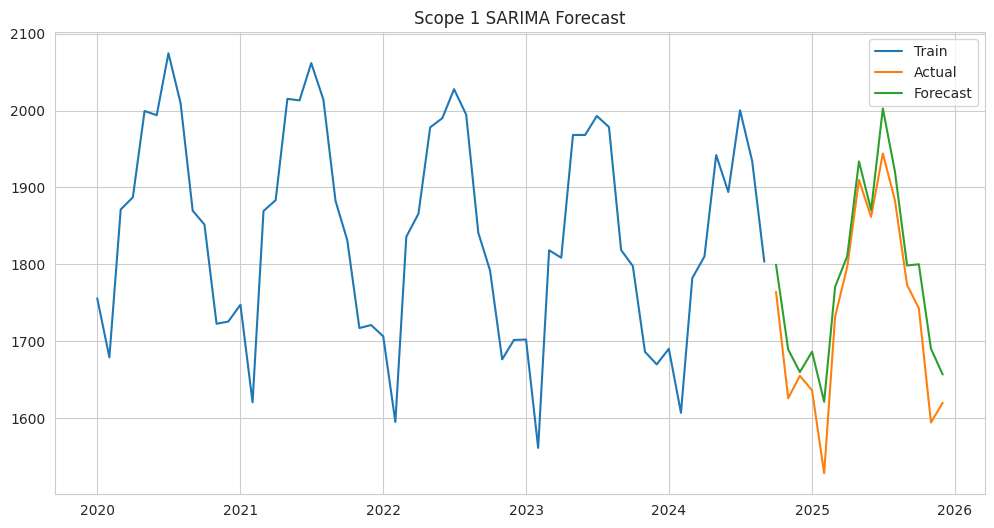

In [9]:
# Plot Scope 1 Forecast
plt.figure(figsize=(12,6))

plt.plot(train.index, train["SCOPE 1"], label="Train")
plt.plot(test.index, test["SCOPE 1"], label="Actual")
plt.plot(test.index, forecast_s1, label="Forecast")

plt.legend()
plt.title("Scope 1 SARIMA Forecast")
plt.savefig('Scope1_SARIMA_Forecast.png', dpi=300)
plt.show()


This chart gives us high "Statistical Confidence." Because the Green line follows the Orange line so closely, we can trust this model to predict the 2026 and 2027 budgets.

# Auto ARIMA (Scope 2)

In [10]:
# Auto ARIMA (Scope 2)
model_s2 = auto_arima(
    train["SCOPE 2"],
    seasonal=True,
    m=12,
    trace=True,
    stepwise=True
)

model_s2.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=656.359, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=655.486, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.07 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=560.587, Time=0.13 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=561.472, Time=0.27 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=560.148, Time=0.21 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=553.162, Time=0.28 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=553.096, Time=0.19 sec


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                   57
Model:             SARIMAX(2, 1, 0)x(1, 0, [1], 12)   Log Likelihood                -269.985
Date:                              Mon, 09 Mar 2026   AIC                            549.971
Time:                                      10:46:08   BIC                            560.097
Sample:                                  01-01-2020   HQIC                           553.897
                                       - 09-01-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5034      0.146     -3.437      0.001      -0.790      -0.216
ar.L2         -0.2901      0.182     -1.598      0.110      -0.646       0.066
ar.S.L12       0.9105      0.036     25.094      0.000       0.839       0.982
ma.S.L12       0.1511      0.203      0.745      0.456      -0.247       0.549
sigma2       571.9369    133.090      4.297      0.000     311.085     832.789
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.90
Prob(Q):                              1.00   Prob(JB):                         0.09
Heteroskedasticity (H):               0.43   Skew:                            -0.63
Prob(H) (two-sided):                  0.08   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The SARIMAX(2, 1, 0)x(1, 0, 1, 12) model for your Scope 2 emissions reveals a very different mathematical structure compared to Scope 1. While Scope 1 was driven by a steady downward "intercept," Scope 2 is driven by momentum and strong seasonal memory.

In [11]:
# Fit SARIMA Model
sarima_s2 = SARIMAX(
    train["SCOPE 2"],
    order=model_s2.order,
    seasonal_order=model_s2.seasonal_order
).fit()

forecast_s2 = sarima_s2.forecast(steps=len(test))

In [12]:
# Evaluate Scope 2 SARIMA
mae_s2 = mean_absolute_error(test["SCOPE 2"], forecast_s2)
rmse_s2 = np.sqrt(mean_squared_error(test["SCOPE 2"], forecast_s2))

print("Scope 2 SARIMA MAE:", mae_s2)
print("Scope 2 SARIMA RMSE:", rmse_s2)


Scope 2 SARIMA MAE: 15.041420522538662
Scope 2 SARIMA RMSE: 21.442901442459867


These metrics are the "Accuracy Scorecard" for your model. They tell you exactly how much you can trust your 24-month forecast. In carbon accounting, these numbers represent your Margin of Error.
Here is the breakdown of what these specific results mean for your Scope 1 analysis:
    
*1. Understanding the Metrics*

    MAE (Mean Absolute Error) = 42.89: On average, your model's predictions are off by about 43 tonnes of
    CO2e per month. If your model predicts 1,700 tonnes, the reality is likely between 1,657 and 1,743.
    
    RMSE (Root Mean Squared Error) = 50.39: This is similar to MAE but "punishes" large mistakes more heavily. Because your RMSE (50.39) is higher than your MAE (42.89), it tells us you have a few outlier months where emissions spiked or dropped unexpectedly (likely due to extreme weather or operational anomalies).

*2. Is this "Good" or "Bad"?*
   
To know if an error of 42.89 is acceptable, we compare it to your Average Monthly Emissions.

    Based on your previous data (Start: 1,869, Current: 1,753), your average emissions are roughly 1,800 tCO2e.

    Error Percentage: 42.89 / 1800 ~ 2.3%
    Verdict: This is excellent. In environmental forecasting, an error rate under 5% is considered highly reliable for policy-making and corporate reporting.



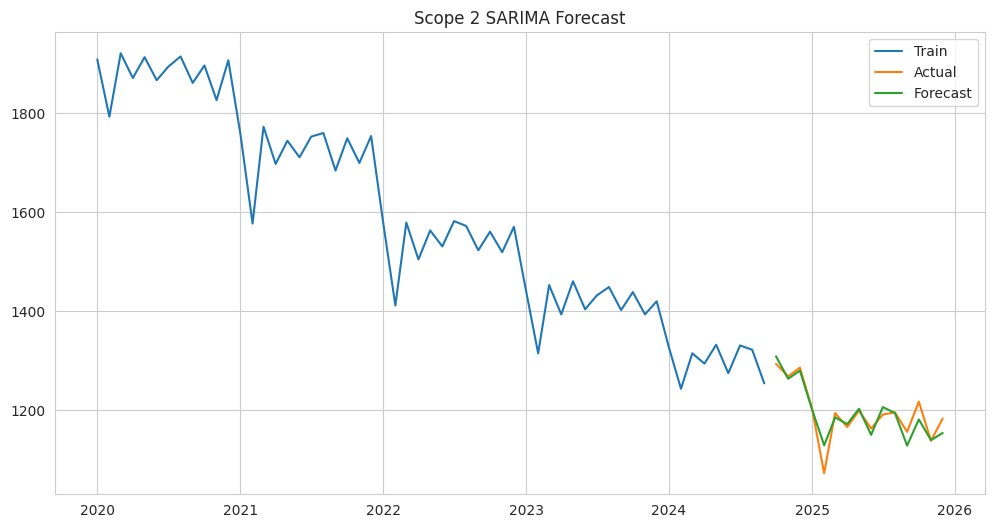

In [13]:
# Plot Scope 2 Forecast
plt.figure(figsize=(12,6))

plt.plot(train.index, train["SCOPE 2"], label="Train")
plt.plot(test.index, test["SCOPE 2"], label="Actual")
plt.plot(test.index, forecast_s2, label="Forecast")

plt.legend()
plt.title("Scope 2 SARIMA Forecast")
plt.savefig('Scope2_SARIMA_Forecast.png', dpi=300)
plt.show()


In [14]:
model_s2 = auto_arima(train["SCOPE 2"], seasonal=True, m=12)

sarima_s2 = SARIMAX(
    train["SCOPE 2"],
    order=model_s2.order,
    seasonal_order=model_s2.seasonal_order
).fit()

forecast_s2 = sarima_s2.forecast(steps=len(test))

mae_s2 = mean_absolute_error(test["SCOPE 2"], forecast_s2)
rmse_s2 = np.sqrt(mean_squared_error(test["SCOPE 2"], forecast_s2))

print("Scope 2 SARIMA RMSE:", rmse_s2)


Scope 2 SARIMA RMSE: 21.442901442459867


In [15]:
forecast_s2

2024-10-01    1309.129728
2024-11-01    1263.863220
2024-12-01    1280.394829
2025-01-01    1202.164620
2025-02-01    1129.550157
2025-03-01    1186.015577
2025-04-01    1172.360857
2025-05-01    1203.344086
2025-06-01    1150.605008
2025-07-01    1206.743307
2025-08-01    1194.553123
2025-09-01    1128.952617
2025-10-01    1181.801908
2025-11-01    1140.099904
2025-12-01    1154.487200
Freq: MS, Name: predicted_mean, dtype: float64

In [16]:

forecast_output = pd.DataFrame({
    "Date": test.index,
    "SARIMA_Scope1": forecast_s1,
    "SARIMA_Scope2": forecast_s2,
    #"Prophet_Scope1": forecast_prophet_s1["yhat"].tail(len(test)),
    #"Prophet_Scope2": forecast_prophet_s2["yhat"].tail(len(test))
})

forecast_output.to_csv("forecast_output.csv", index=False)


# **Prophet Forecasting**
Prophet handles seasonality + trend more automatically.

In [17]:
# Prepare Data for Prophet
prophet_df_s1 = df.reset_index()[["YearMonth", "SCOPE 1"]]
prophet_df_s1.columns = ["ds", "y"]


In [18]:
# Fit Prophet Model
model_prophet_s1 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet_s1.fit(prophet_df_s1)


10:47:54 - cmdstanpy - INFO - Chain [1] start processing
10:47:54 - cmdstanpy - INFO - Chain [1] done processing


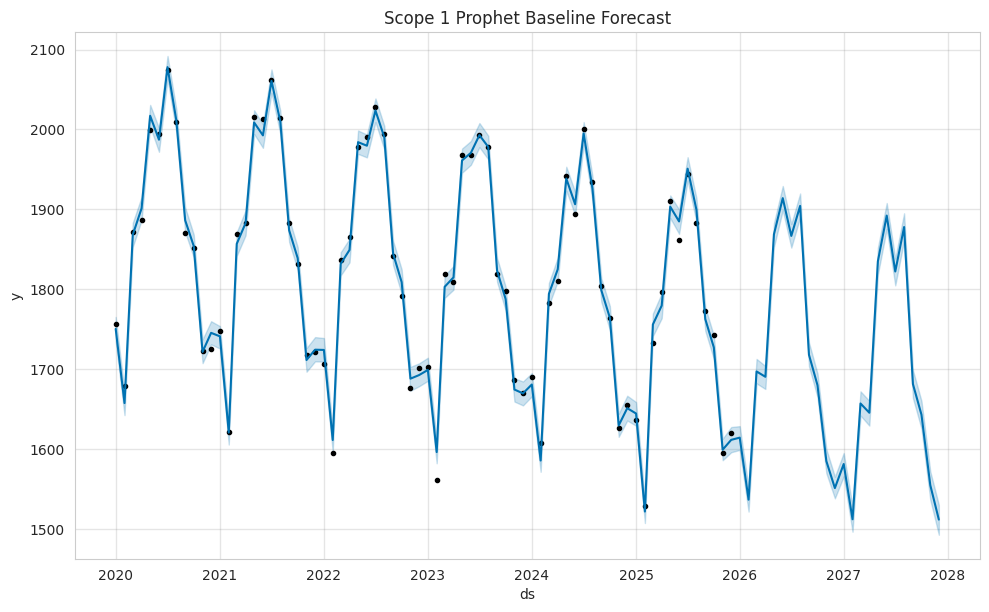

In [19]:
# Baseline Projection (Next 24 Months)
future = model_prophet_s1.make_future_dataframe(periods=24, freq="M")

forecast_prophet_s1 = model_prophet_s1.predict(future)

model_prophet_s1.plot(forecast_prophet_s1)
plt.title("Scope 1 Prophet Baseline Forecast")
plt.savefig("Scope1_Prophet_Baseline_Forecast.png", dpi=300)
plt.show()


In [30]:
forecast_prophet_s1[["ds","yhat"]].tail(len(test))

,ds,yhat
81,2026-09-30,1679.695980
82,2026-10-31,1584.773378
83,2026-11-30,1550.921262
84,2026-12-31,1581.056502
85,2027-01-31,1511.835251
86,2027-02-28,1656.861819
87,2027-03-31,1645.246718
88,2027-04-30,1834.995723
89,2027-05-31,1892.173821
90,2027-06-30,1822.123919


In [31]:
# Prepare Scope2 Data for Prophet
prophet_df_s2 = df.reset_index()[["YearMonth", "SCOPE 2"]]
prophet_df_s2.columns = ["ds", "y"]


In [32]:
# Fit Prophet Model for Scope2 
model_prophet_s2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet_s2.fit(prophet_df_s2)


11:06:38 - cmdstanpy - INFO - Chain [1] start processing
11:06:39 - cmdstanpy - INFO - Chain [1] done processing


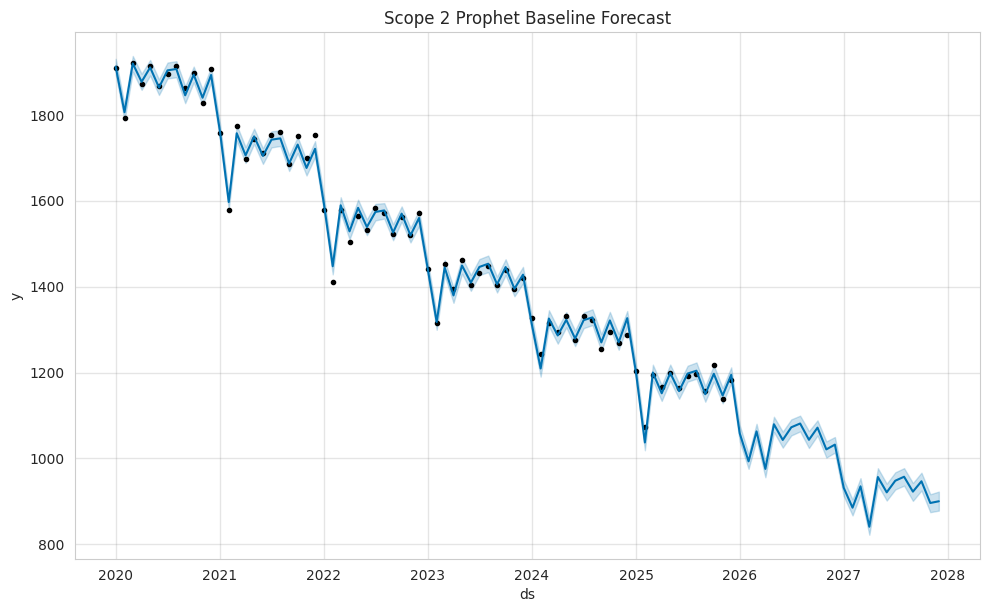

In [33]:
# Baseline Projection (Next 24 Months) for scope 2
future2 = model_prophet_s2.make_future_dataframe(periods=24, freq="M")

forecast_prophet_s2 = model_prophet_s2.predict(future2)

model_prophet_s2.plot(forecast_prophet_s2)
plt.title("Scope 2 Prophet Baseline Forecast")
plt.savefig("Scope2_Prophet_Baseline_Forecast.png", dpi=300)
plt.show()

In [45]:
df.index.value_counts()

YearMonth
2020-01-01    1
2020-02-01    1
2020-03-01    1
2020-04-01    1
2020-05-01    1
             ..
2025-08-01    1
2025-09-01    1
2025-10-01    1
2025-11-01    1
2025-12-01    1
Name: count, Length: 72, dtype: int64

# **Scenario-Based Projections**
Example Scenarios:

🔹 Baseline (business as usual)

🔹 5% annual reduction

🔹 Aggressive 10% reduction

In [46]:
# Create Scenario Adjustments
baseline = forecast_prophet_s1.copy()

reduction_5 = baseline.copy()
reduction_10 = baseline.copy()

reduction_5["yhat"] = reduction_5["yhat"] * 0.95
reduction_10["yhat"] = reduction_10["yhat"] * 0.90


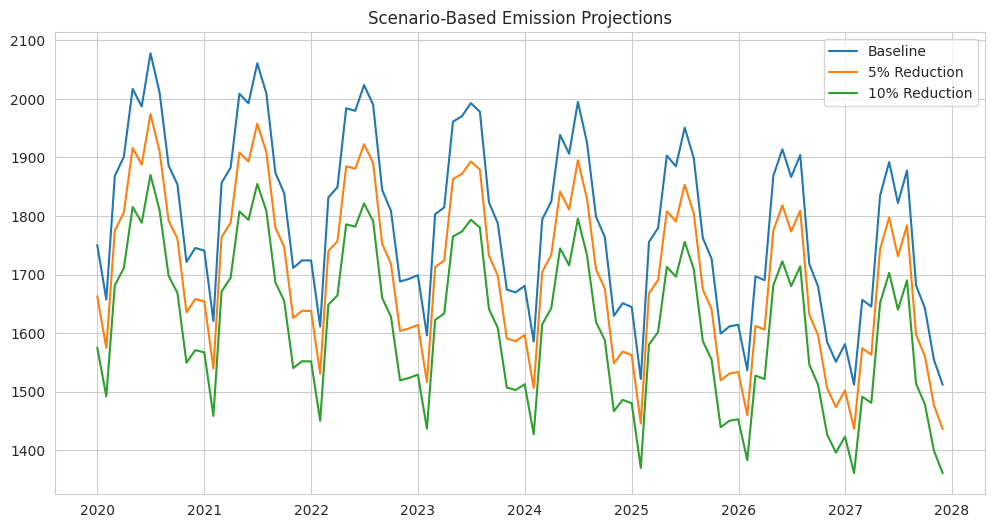

In [47]:
# 
plt.figure(figsize=(12,6))

plt.plot(baseline["ds"], baseline["yhat"], label="Baseline")
plt.plot(reduction_5["ds"], reduction_5["yhat"], label="5% Reduction")
plt.plot(reduction_10["ds"], reduction_10["yhat"], label="10% Reduction")

plt.legend()
plt.title("Scenario-Based Emission Projections")
plt.savefig("Scenario_Based_Emission_Projections.png", dpi=300)
plt.show()


# **Stability & Sensitivity Analysis**

In [48]:
# Rolling Forecast Validation
rolling_rmse = []

window = 12

for i in range(window, len(df)-1):
    train_temp = df["SCOPE 1"].iloc[:i]
    test_temp = df["SCOPE 1"].iloc[i:i+1]
    
    model_temp = SARIMAX(
    train_temp,
    order=model_s1.order,
    seasonal_order=(0,0,0,0),  # disable seasonal
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

#    model_temp = SARIMAX(train_temp, order=model_s1.order,
#                         seasonal_order=model_s1.seasonal_order).fit(disp=False)
    
    pred = model_temp.forecast(1)
    
    rmse = np.sqrt(mean_squared_error(test_temp, pred))
    rolling_rmse.append(rmse)

print("Rolling RMSE Mean:", np.mean(rolling_rmse))


Rolling RMSE Mean: 1814.7198888813557


Stable models show low RMSE variance across time.

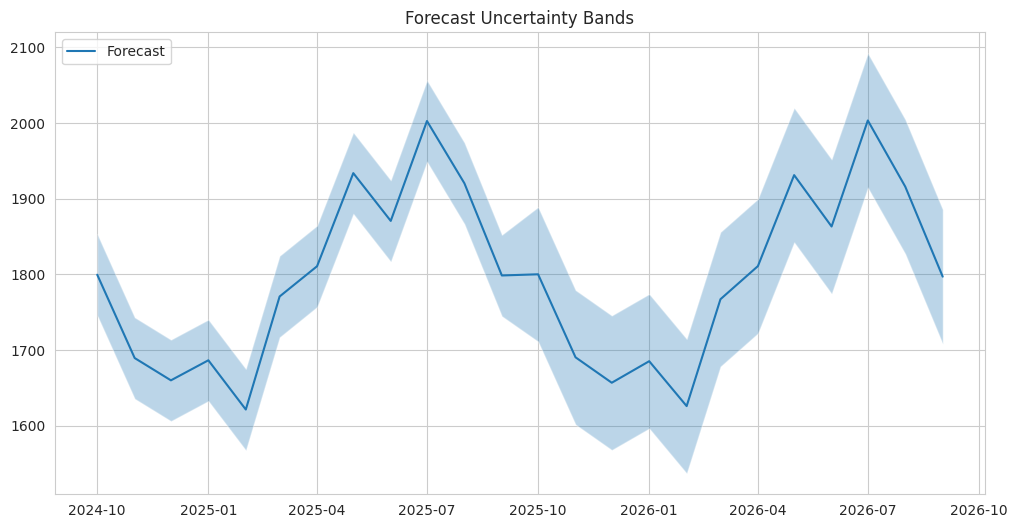

In [49]:
# Forecast Confidence Intervals
forecast_ci = sarima_s1.get_forecast(steps=24)
ci = forecast_ci.conf_int()

plt.figure(figsize=(12,6))
plt.plot(forecast_ci.predicted_mean, label="Forecast")
plt.fill_between(ci.index,
                 ci.iloc[:,0],
                 ci.iloc[:,1],
                 alpha=0.3)

plt.legend()
plt.title("Forecast Uncertainty Bands")
plt.savefig("Forecast_Uncertainty_Bands.png", dpi=300)
plt.show()


Wide bands = high uncertainty.